# LDPC ECC

## Dependencies

In [63]:
# !pip install stim~=1.15
# !pip install numpy~=1.0  # 1.0 instead of 2.0 for pymatching compatibility later
# !pip install scipy
# !pip install pymatching~=2.0
# !pip install sinter~=1.14
!pip install ldpc
!pip install stimbposd


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Import

In [57]:
import stim
import sinter
from typing import List
import pymatching

print(stim.__version__)

1.15.0


## Circuit Creation Functions

In [ ]:
import numpy as np
from stimbposd import BPOSD

def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> int:
    sampler = circuit.compile_detector_sampler()
    shots, observables = sampler.sample(num_shots, separate_observables=True)

    decoder = BPOSD(circuit.detector_error_model(), max_bp_iters=20)

    predicted_observables = decoder.decode_batch(shots)
    num_mistakes = np.sum(np.any(predicted_observables != observables, axis=1))

    return num_mistakes

In [ ]:
def gen_ldpc_shift_matrix(d, k, data_anc_conn, anc_data_conn):
    H = [
        [1,1,1,1,0,0,0,0,0,0,0,0],
        [0,0,0,0,1,1,1,1,0,0,0,0],
        [0,0,0,0,0,0,0,0,1,1,1,1],
        # [1,1,0,0,1,1,0,0,1,1,0,0],
        # [0,1,0,1,0,1,0,1,0,1,0,1],
    ]
    # for i in k:
    #     for j in d:
    return H

def gen_ldpc_circuit(d, k, data_anc_conn, anc_data_conn, prob) -> stim.Circuit:
    H = gen_ldpc_shift_matrix(d,k,data_anc_conn,anc_data_conn)
    circuit = stim.Circuit()
    data = list(range(d))
    anc = list(range(d,2*d-k))
    print(f"data : {data}  anc: {anc}")
    circuit.append("R", data + anc)
    circuit.append("X_ERROR", data, prob)
    circuit.append("H", anc)
    for i in range(0, d-k):
        rec = 0
        for j in range(0, d):
            if(H[i][j] == 1):
                circuit.append("CZ", [anc[i], j])
                rec += 1   
        circuit.append("H", anc[i])
        circuit.append("M", anc[i])
        circuit.append("DETECTOR", [stim.target_rec(-1)])
    
    circuit.append("M", data)
    for i in range(0,d-k):
        rec = []
        for j in range(0,d):
            if(H[i][j] == 1):
                print(f"{d-k+j}")
                rec.append(stim.target_rec(-d+j))
        print(rec)
        circuit.append("OBSERVABLE_INCLUDE", rec,0)

 
    return circuit

## Circuit Simulation

data : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]  anc: [12, 13, 14]
3
4
5
6
[stim.target_rec(-12), stim.target_rec(-11), stim.target_rec(-10), stim.target_rec(-9)]
7
8
9
10
[stim.target_rec(-8), stim.target_rec(-7), stim.target_rec(-6), stim.target_rec(-5)]
11
12
13
14
[stim.target_rec(-4), stim.target_rec(-3), stim.target_rec(-2), stim.target_rec(-1)]


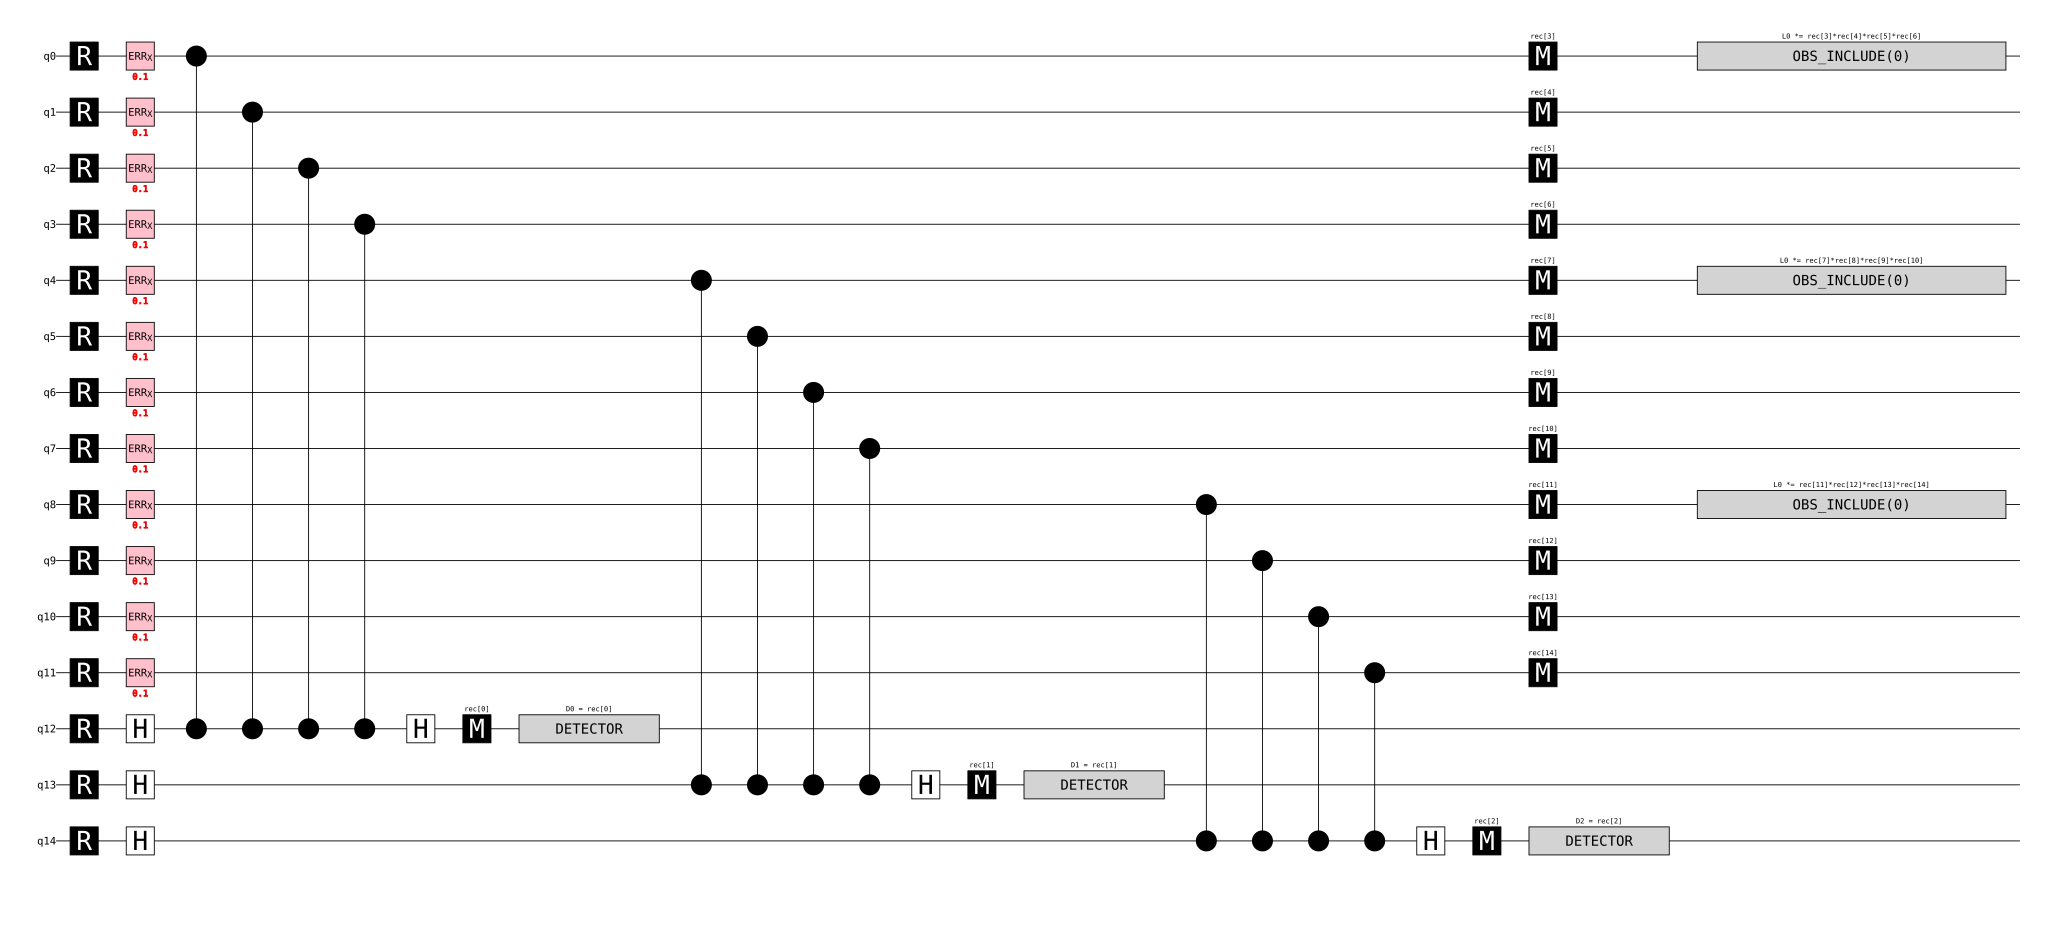

In [113]:
circuit = gen_ldpc_circuit(12,9,0,0,0.1)
circuit.diagram('timeline-svg')

## Results

In [115]:
num_shots = 1_000_000
num_logical_errors = count_logical_errors(circuit, num_shots)
print("there were", num_logical_errors, "wrong predictions (logical errors) out of", num_shots, "shots")

0/1000000
there were None wrong predictions (logical errors) out of 1000000 shots


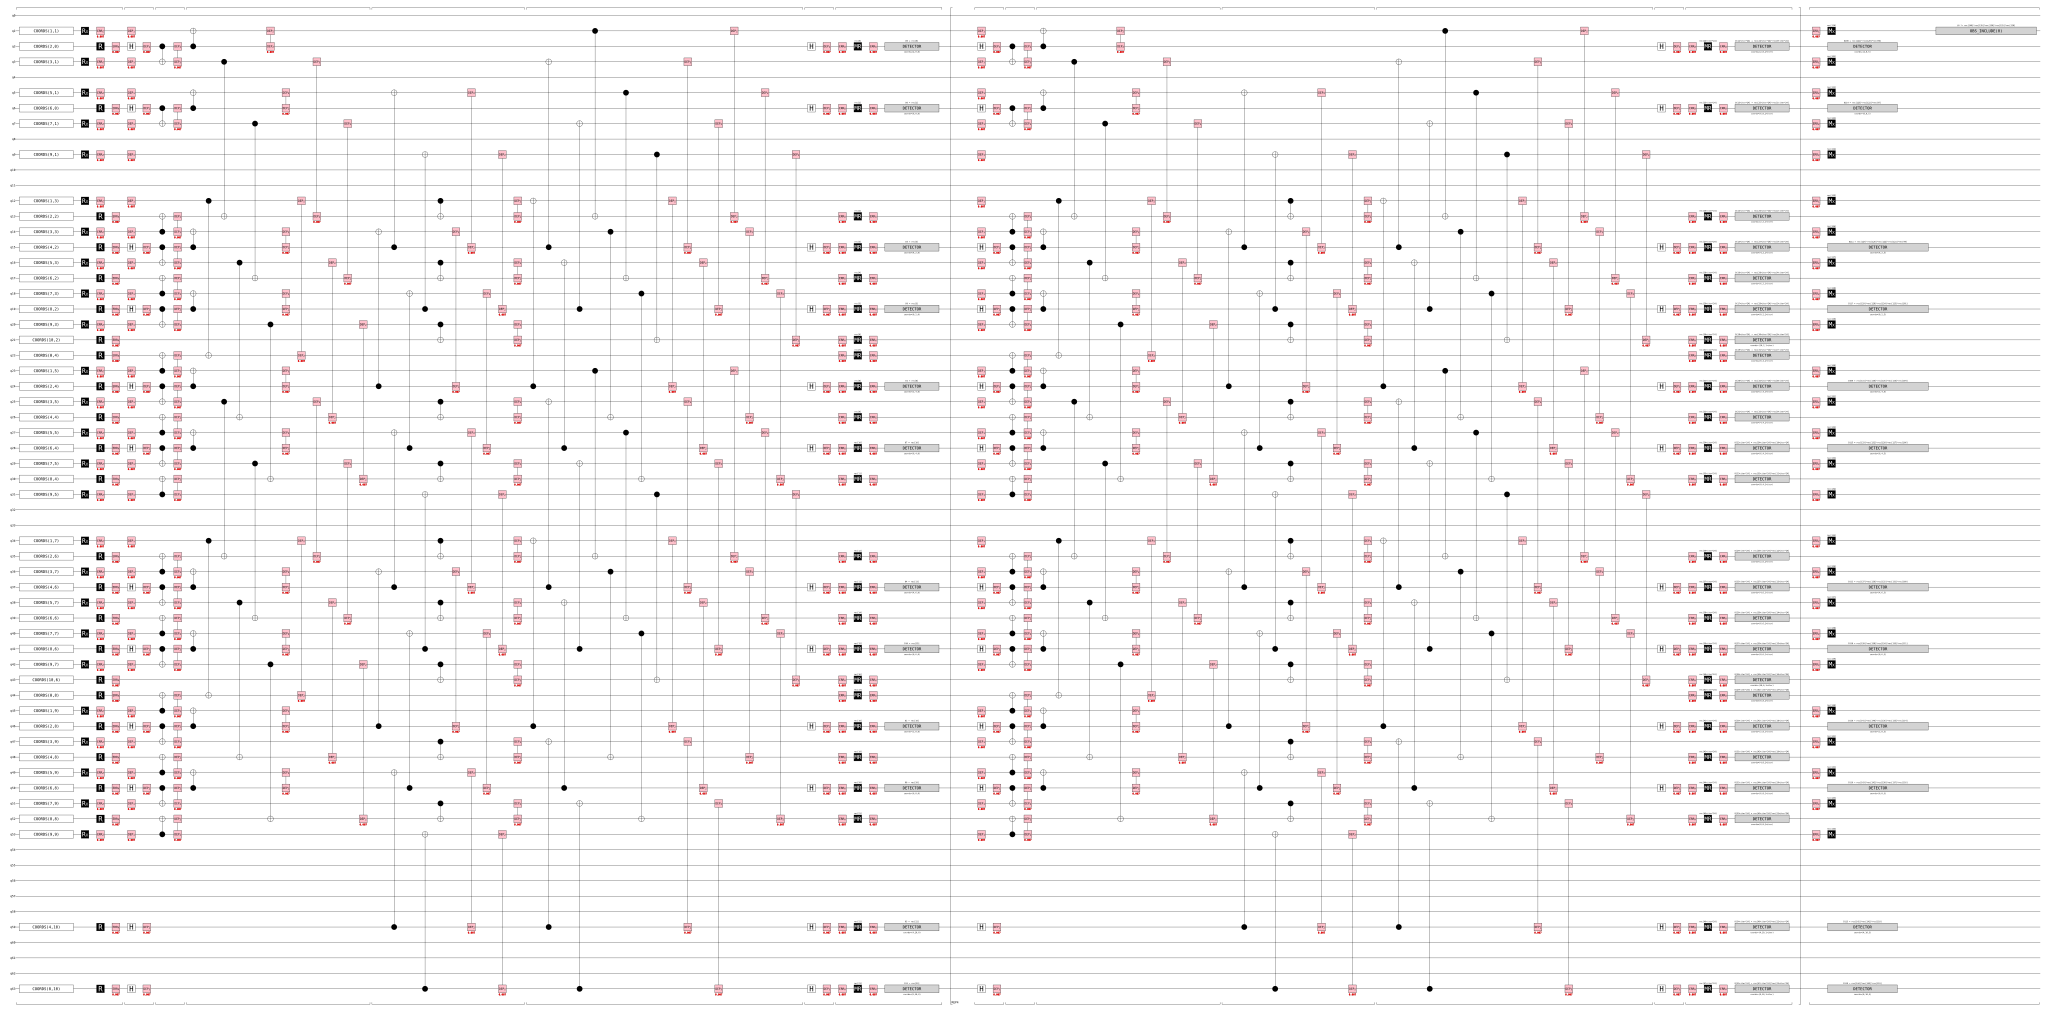

In [74]:
num_shots = 100
d = 5
p = 0.007
circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_x",
    rounds=d,
    distance=d,
    before_round_data_depolarization=p,
    before_measure_flip_probability=p,
    after_reset_flip_probability=p,
    after_clifford_depolarization=p
)
circuit.diagram('timeline-svg')